# **PART ONE:**

DOMAIN: Electronics and Telecommunication

• CONTEXT: A communications equipment manufacturing company has a product which is responsible for emitting informative signals. Company wants to build a machine learning model which can help the company to predict the
equipment’s signal quality using various parameters.

• DATA DESCRIPTION: The data set contains information on various signal tests performed:

1. Parameters: Various measurable signal parameters.
2. Signal_Quality: Final signal strength or quality

• PROJECT OBJECTIVE: The need is to build a regressor which can use these parameters to determine the signal strength or quality [as number].

Steps and tasks: [ Total Score: 10 points]

1. Import data.
2. Data analysis & visualisation
• Perform relevant and detailed statistical analysis on the data.
• Perform relevant and detailed uni, bi and multi variate analysis.
Hint: Use your best analytical approach. Even you can mix match columns to create new columns which can be used for better
analysis. Create your own features if required. Be highly experimental and analytical here to find relevant hidden patterns.
3. Design, train, tune and test a neural network regressor.
Hint: Use best approach to refine and tune the data or the model. Be highly experimental here.
4. Pickle the model for future use.

In [82]:
# this allows plots to appear directly in the notebook
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import datasets

%tensorflow_version 2.x
import tensorflow as tf
import keras

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import pickle

In [83]:
tf.random.set_seed(42)

In [84]:
#prepare axccess to GDrive
#Mount your Google drive so you can read them easilu
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [85]:
import os
os.chdir('/content/gdrive/MyDrive/Colab Notebooks/NN/External Assessment')
os.getcwd()

'/content/gdrive/MyDrive/Colab Notebooks/NN/External Assessment'

Step 1: Import data.

In [86]:
#Import data

df_telecom=pd.read_csv('Signal.csv', error_bad_lines=False, encoding="latin-1")
df_telecom.head(5)

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [87]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Parameter 1      1599 non-null   float64
 1   Parameter 2      1599 non-null   float64
 2   Parameter 3      1599 non-null   float64
 3   Parameter 4      1599 non-null   float64
 4   Parameter 5      1599 non-null   float64
 5   Parameter 6      1599 non-null   float64
 6   Parameter 7      1599 non-null   float64
 7   Parameter 8      1599 non-null   float64
 8   Parameter 9      1599 non-null   float64
 9   Parameter 10     1599 non-null   float64
 10  Parameter 11     1599 non-null   float64
 11  Signal_Strength  1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Step 2:
Data analysis & visualisation 

• Perform relevant and detailed statistical analysis on the data.

• Perform relevant and detailed uni, bi and multi variate analysis. 

Hint: Use your best analytical approach. Even you can mix match columns to create new columns which can be used for better analysis. Create your own features if required. Be highly experimental and analytical here to find relevant hidden patterns.

In [88]:
df_telecom.describe().T

,count,mean,std,min,25%,50%,75%,max
Parameter 1,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
Parameter 2,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
Parameter 3,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
Parameter 4,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
Parameter 5,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
Parameter 6,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
Parameter 7,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
Parameter 8,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
Parameter 9,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
Parameter 10,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [89]:
#Check for missing value
df_telecom.isnull().sum()

Parameter 1        0
Parameter 2        0
Parameter 3        0
Parameter 4        0
Parameter 5        0
Parameter 6        0
Parameter 7        0
Parameter 8        0
Parameter 9        0
Parameter 10       0
Parameter 11       0
Signal_Strength    0
dtype: int64

In [90]:
##Identify duplicates records in the data
dupes = df_telecom.duplicated()
sum(dupes)

240

In [91]:
df_telecom.drop_duplicates(keep='first', inplace=True)

In [92]:
df_telecom['Signal_Strength'] = np.array(df_telecom['Signal_Strength']).astype('float32')

In [93]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Parameter 1      1359 non-null   float64
 1   Parameter 2      1359 non-null   float64
 2   Parameter 3      1359 non-null   float64
 3   Parameter 4      1359 non-null   float64
 4   Parameter 5      1359 non-null   float64
 5   Parameter 6      1359 non-null   float64
 6   Parameter 7      1359 non-null   float64
 7   Parameter 8      1359 non-null   float64
 8   Parameter 9      1359 non-null   float64
 9   Parameter 10     1359 non-null   float64
 10  Parameter 11     1359 non-null   float64
 11  Signal_Strength  1359 non-null   float32
dtypes: float32(1), float64(11)
memory usage: 132.7 KB


In [94]:
df_telecom['Signal_Strength'].value_counts()

5.0    577
6.0    535
7.0    167
4.0     53
8.0     17
3.0     10
Name: Signal_Strength, dtype: int64

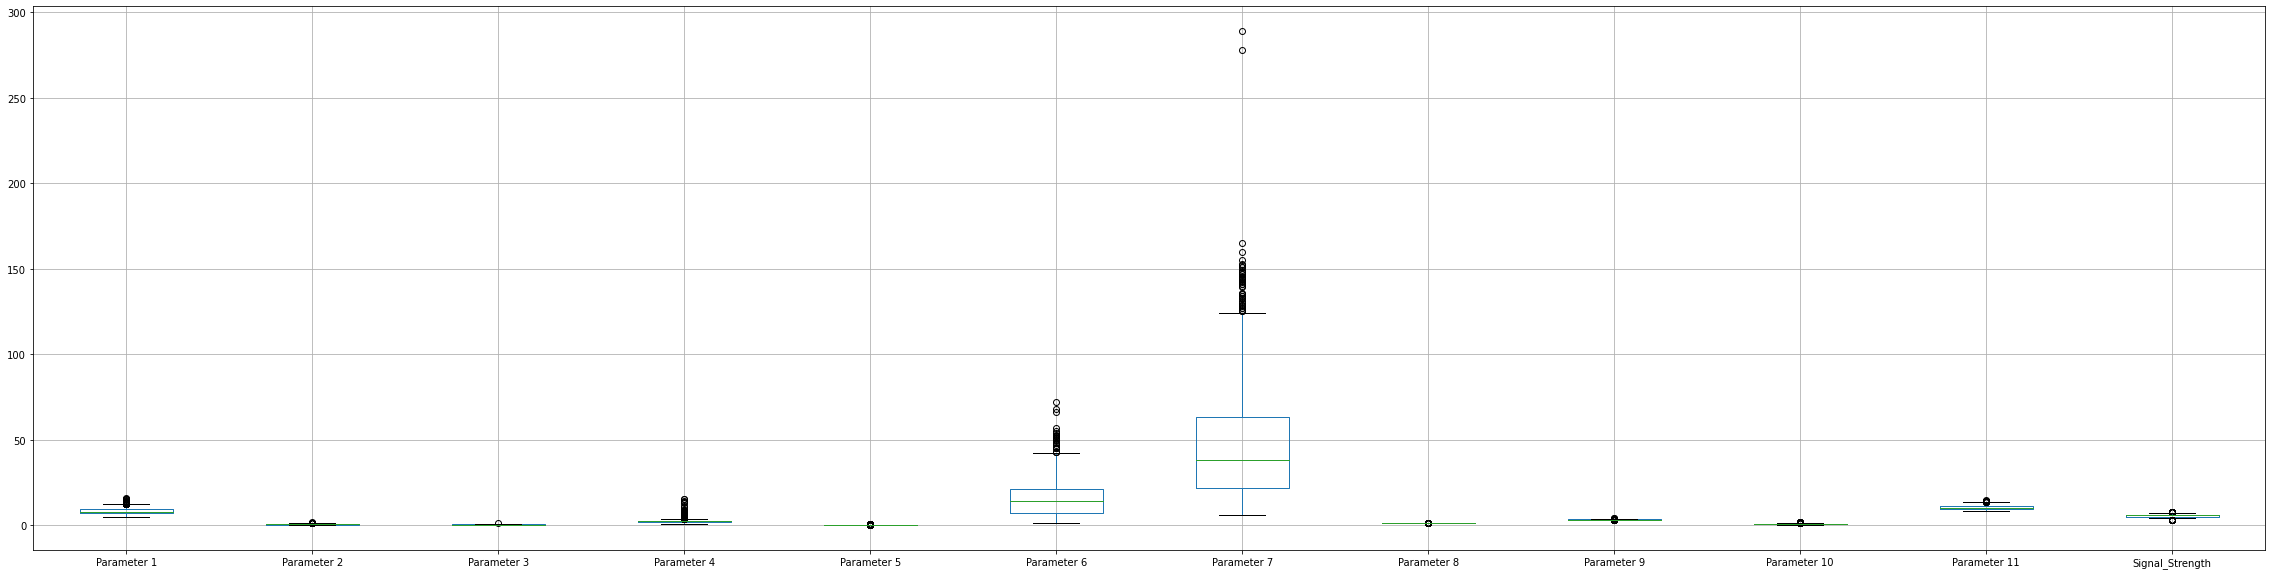

In [95]:
df_telecom.boxplot(figsize=(40,10))

In [96]:
#Treat Outliers
def out_iqr(df_telecom , column):
    global lower,upper
    q25, q75 = np.quantile(df_telecom[column], 0.25), np.quantile(df_telecom[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df_telecom[df_telecom[column] > upper]
    df2 = df_telecom[df_telecom[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [97]:
out_iqr(df_telecom, 'Parameter 1')

The IQR is 2.0999999999999996
The lower bound value is 3.95
The upper bound value is 12.349999999999998
Total number of outliers are 41


In [98]:
df_telecom.loc[df_telecom['Parameter 1'] > 12, 'Parameter 1'] = 12
df_telecom.loc[df_telecom['Parameter 1'] < 3.95, 'Parameter 1'] = 3.95

In [99]:
out_iqr(df_telecom, 'Parameter 2')

The IQR is 0.25
The lower bound value is 0.015000000000000013
The upper bound value is 1.0150000000000001
Total number of outliers are 19


In [100]:
df_telecom.loc[df_telecom['Parameter 2'] > 1.01, 'Parameter 2'] = 1
df_telecom.loc[df_telecom['Parameter 2'] < 0.01, 'Parameter 2'] = 0.01

In [101]:
out_iqr(df_telecom, 'Parameter 3')

The IQR is 0.33999999999999997
The lower bound value is -0.42000000000000004
The upper bound value is 0.94
Total number of outliers are 1


In [102]:
df_telecom.loc[df_telecom['Parameter 3'] > 0.91, 'Parameter 3'] = 0.9
df_telecom.loc[df_telecom['Parameter 3'] < 0.4, 'Parameter 3'] = 0

In [103]:
out_iqr(df_telecom, 'Parameter 4')

The IQR is 0.7000000000000002
The lower bound value is 0.8499999999999996
The upper bound value is 3.6500000000000004
Total number of outliers are 126


In [104]:
df_telecom.loc[df_telecom['Parameter 4'] > 3.55, 'Parameter 4'] = 3.50
df_telecom.loc[df_telecom['Parameter 4'] < 0.75, 'Parameter 4'] = 0.75

In [105]:
out_iqr(df_telecom, 'Parameter 5')

The IQR is 0.02099999999999999
The lower bound value is 0.03850000000000002
The upper bound value is 0.12249999999999998
Total number of outliers are 87


In [106]:
df_telecom.loc[df_telecom['Parameter 5'] > 0.10, 'Parameter 5'] = 0.10
df_telecom.loc[df_telecom['Parameter 5'] < 0.04, 'Parameter 5'] = 0.04

In [107]:
out_iqr(df_telecom, 'Parameter 6')

The IQR is 14.0
The lower bound value is -14.0
The upper bound value is 42.0
Total number of outliers are 26


In [108]:
df_telecom.loc[df_telecom['Parameter 6'] > 42.0, 'Parameter 6'] = 42.0
df_telecom.loc[df_telecom['Parameter 6'] < 0, 'Parameter 6'] = 0

In [109]:
out_iqr(df_telecom, 'Parameter 7')

The IQR is 41.0
The lower bound value is -39.5
The upper bound value is 124.5
Total number of outliers are 45


In [110]:
df_telecom.loc[df_telecom['Parameter 7'] > 122.0, 'Parameter 7'] = 122.0
df_telecom.loc[df_telecom['Parameter 7'] < 0, 'Parameter 7'] = 0

In [111]:
out_iqr(df_telecom, 'Parameter 8')

The IQR is 0.0022199999999999998
The lower bound value is 0.99227
The upper bound value is 1.00115
Total number of outliers are 35


In [112]:
df_telecom.loc[df_telecom['Parameter 8'] > 1.0, 'Parameter 8'] = 1.0
df_telecom.loc[df_telecom['Parameter 8'] < 0.9, 'Parameter 8'] = 0.8

In [113]:
out_iqr(df_telecom, 'Parameter 9')

The IQR is 0.18999999999999995
The lower bound value is 2.925
The upper bound value is 3.6849999999999996
Total number of outliers are 28


In [114]:
df_telecom.loc[df_telecom['Parameter 9'] > 3.5, 'Parameter 9'] = 3
df_telecom.loc[df_telecom['Parameter 9'] < 2.5, 'Parameter 9'] = 2

In [115]:
out_iqr(df_telecom, 'Parameter 10')

The IQR is 0.17999999999999994
The lower bound value is 0.28000000000000014
The upper bound value is 0.9999999999999999
Total number of outliers are 55


In [116]:
df_telecom.loc[df_telecom['Parameter 10'] > 0.99, 'Parameter 10'] = 0.99
df_telecom.loc[df_telecom['Parameter 10'] < 0.2, 'Parameter 10'] = 0.2

In [117]:
out_iqr(df_telecom, 'Parameter 11')

The IQR is 1.5999999999999996
The lower bound value is 7.1000000000000005
The upper bound value is 13.5
Total number of outliers are 12


In [118]:
df_telecom.loc[df_telecom['Parameter 11'] > 13.5, 'Parameter 11'] = 13
df_telecom.loc[df_telecom['Parameter 11'] < 7, 'Parameter 11'] = 7

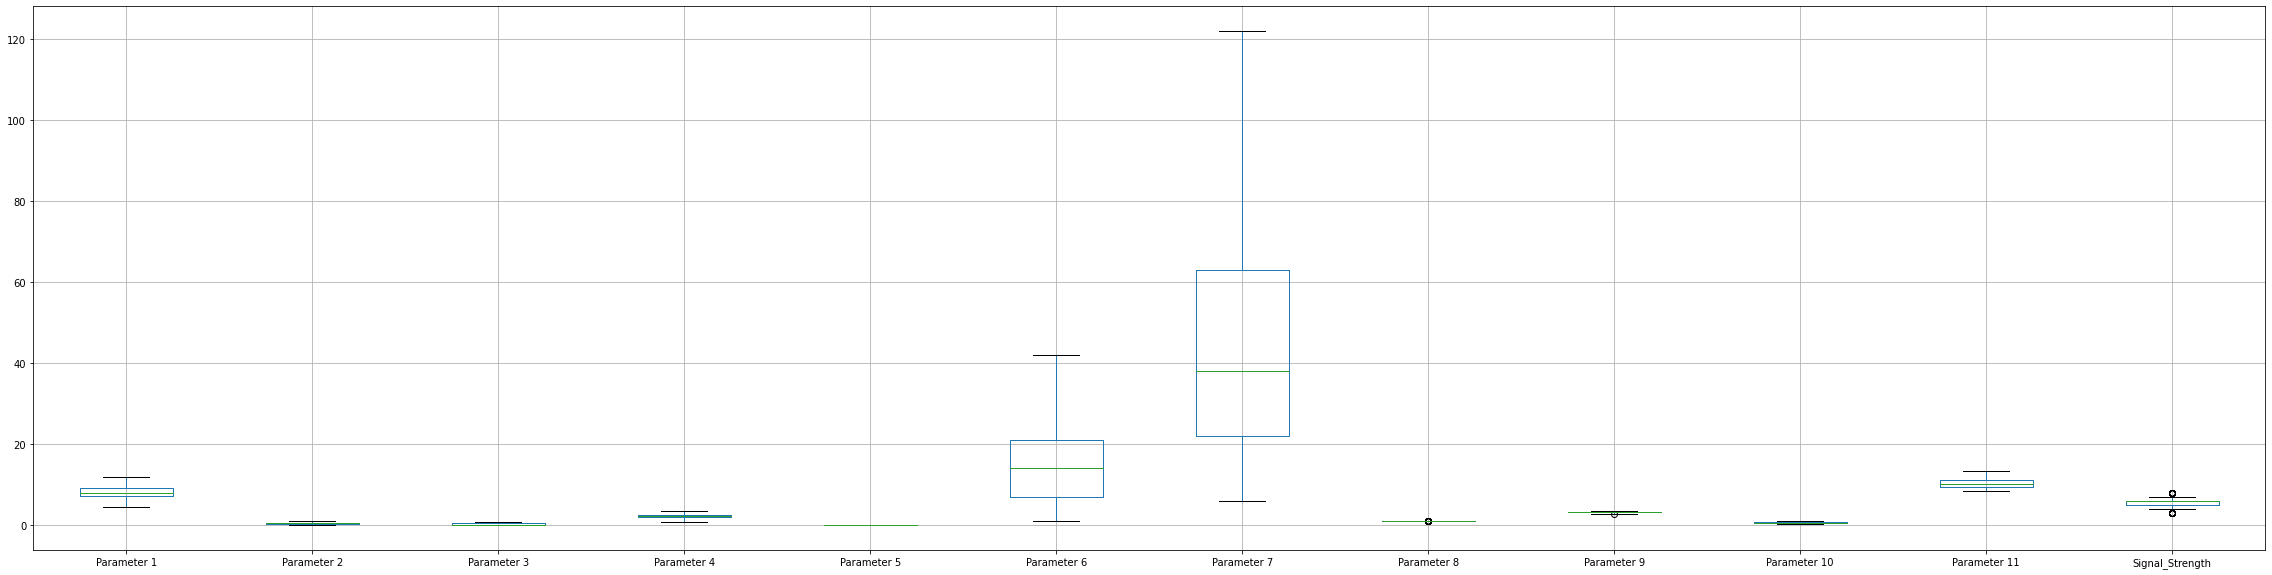

In [119]:
#Outlier removal
df_telecom.boxplot(figsize=(40,10))

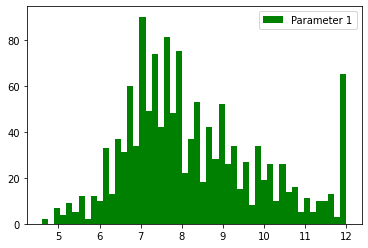

In [120]:
#Univariate Analysis
_= plt.hist(df_telecom.iloc[:,0] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[0]])

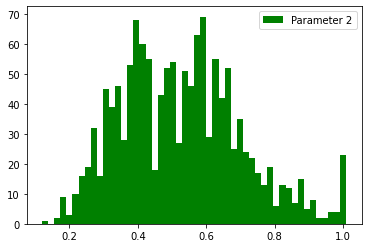

In [121]:
_= plt.hist(df_telecom.iloc[:,1] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[1]])

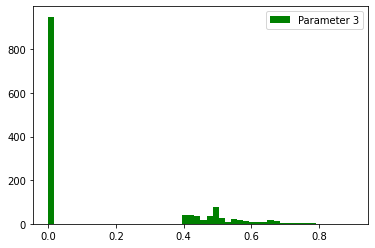

In [122]:
_= plt.hist(df_telecom.iloc[:,2] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[2]])

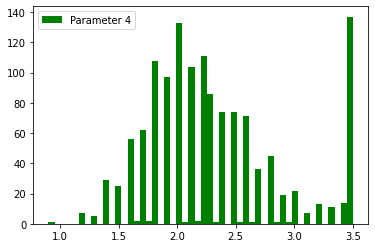

In [123]:
_= plt.hist(df_telecom.iloc[:,3] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[3]])

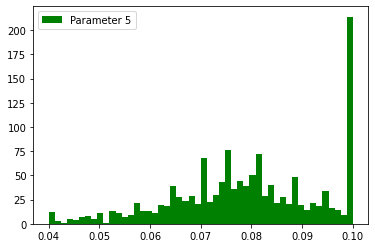

In [124]:
_= plt.hist(df_telecom.iloc[:,4] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[4]])

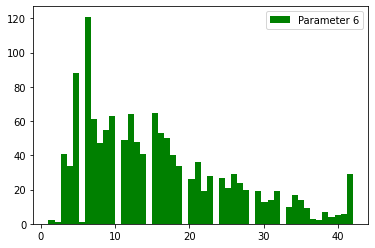

In [125]:
_= plt.hist(df_telecom.iloc[:,5] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[5]])

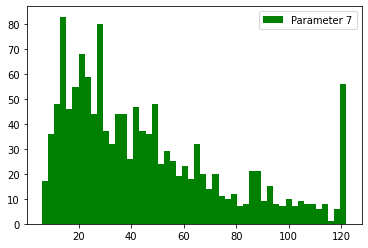

In [126]:
_= plt.hist(df_telecom.iloc[:,6] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[6]])

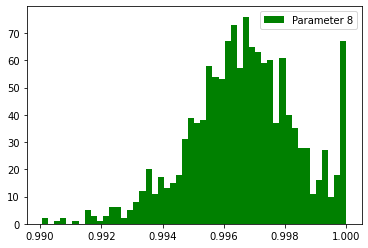

In [127]:
_= plt.hist(df_telecom.iloc[:,7] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[7]])

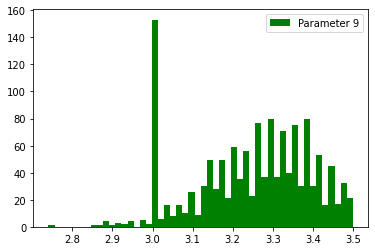

In [128]:
_= plt.hist(df_telecom.iloc[:,8] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[8]])

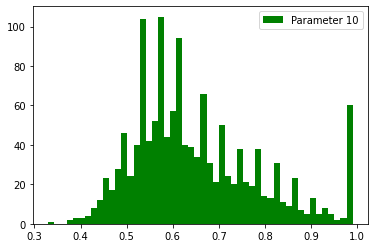

In [129]:
_= plt.hist(df_telecom.iloc[:,9] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[9]])

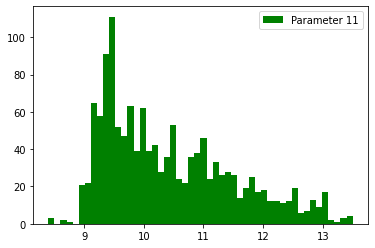

In [130]:
_= plt.hist(df_telecom.iloc[:,10] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[10]])

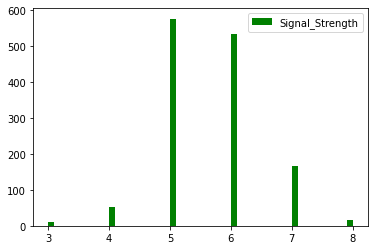

In [131]:
_= plt.hist(df_telecom.iloc[:,11] , 50, facecolor='green', alpha=1)
plt.legend([list(df_telecom)[11]])

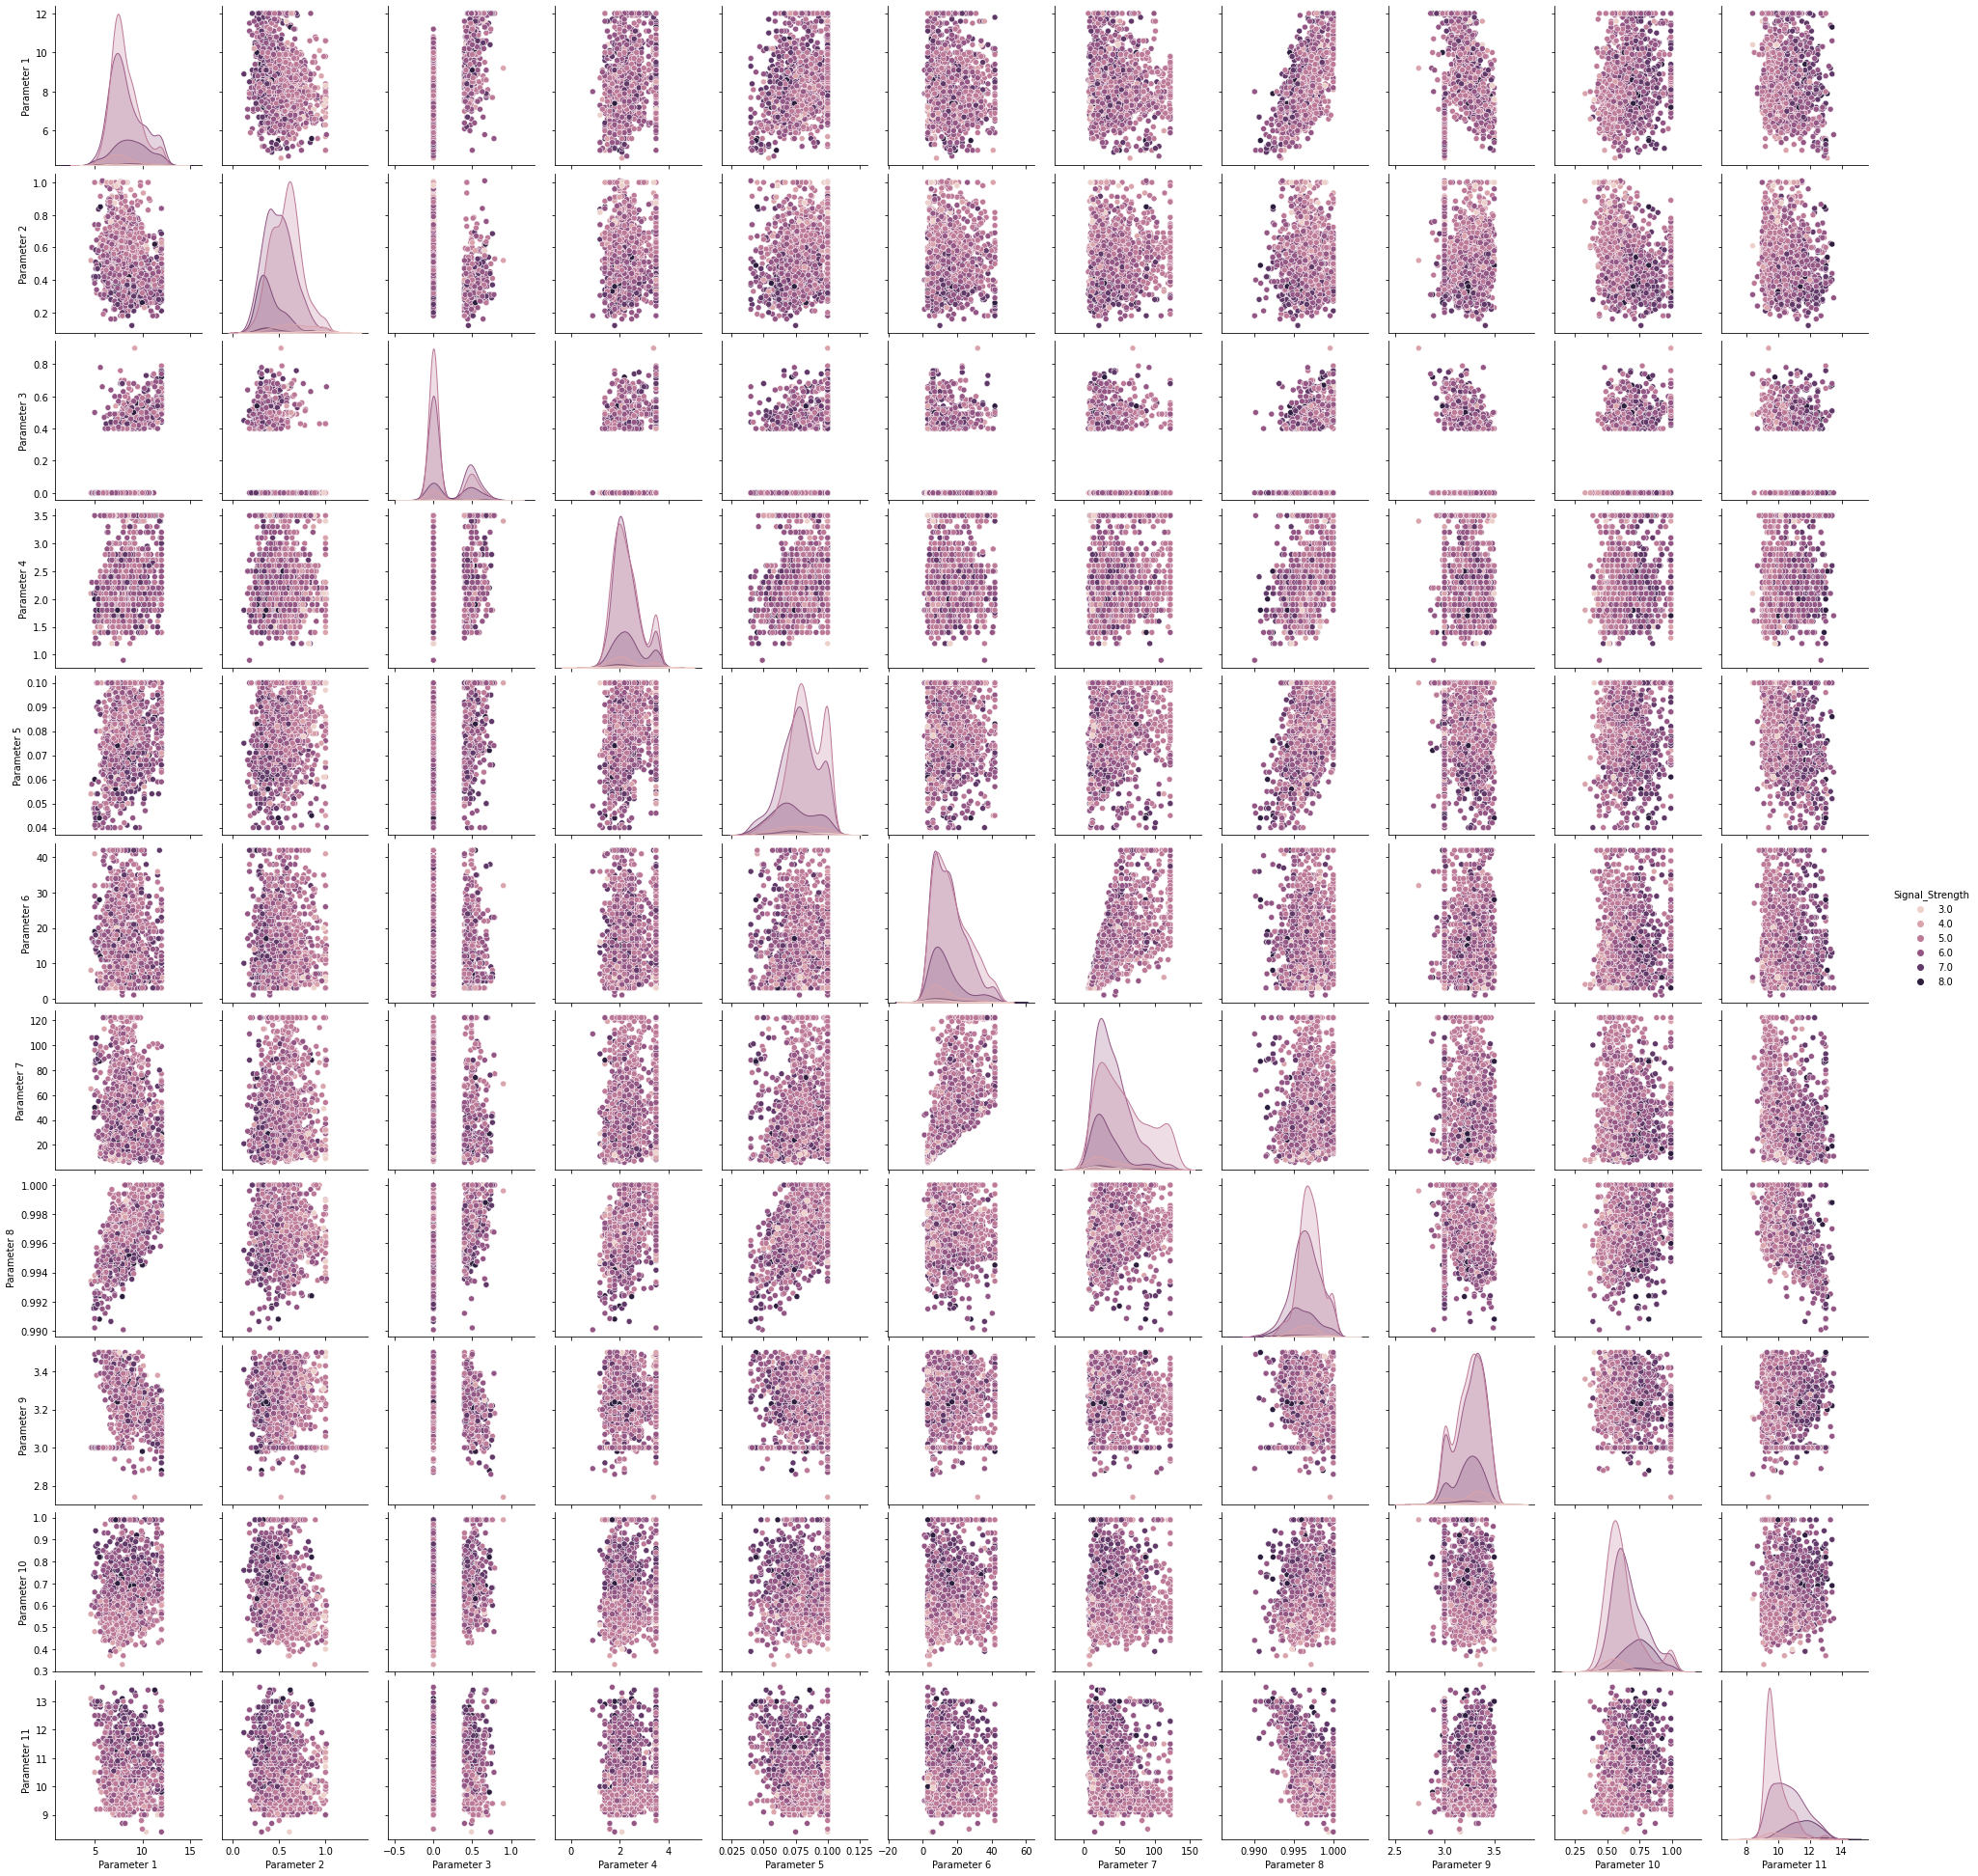

In [132]:
#Lets visualize the data using pair plot - Multi-variate Analysis
sns.pairplot(df_telecom,diag_kind='kde',hue='Signal_Strength')

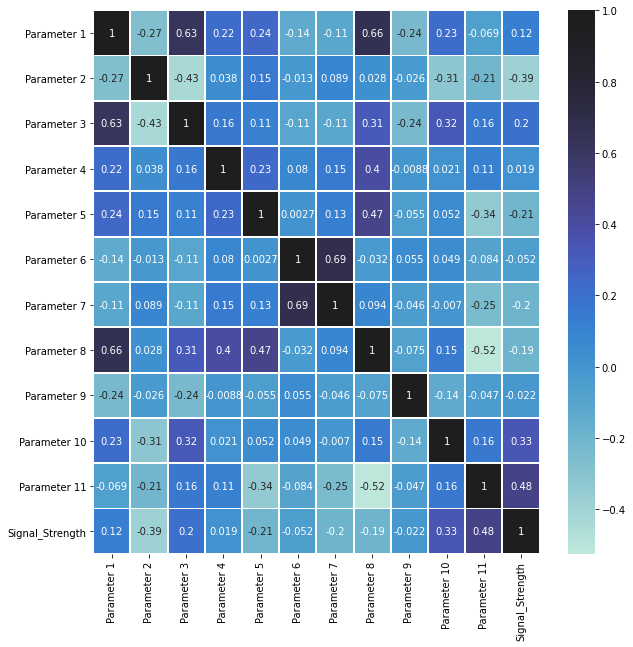

In [133]:
corr=df_telecom.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, linewidths=1.0, xticklabels=corr.columns.values, yticklabels=corr.columns.values, center = 1)  # plot the correlation coefficients as a heatmap
plt.show()

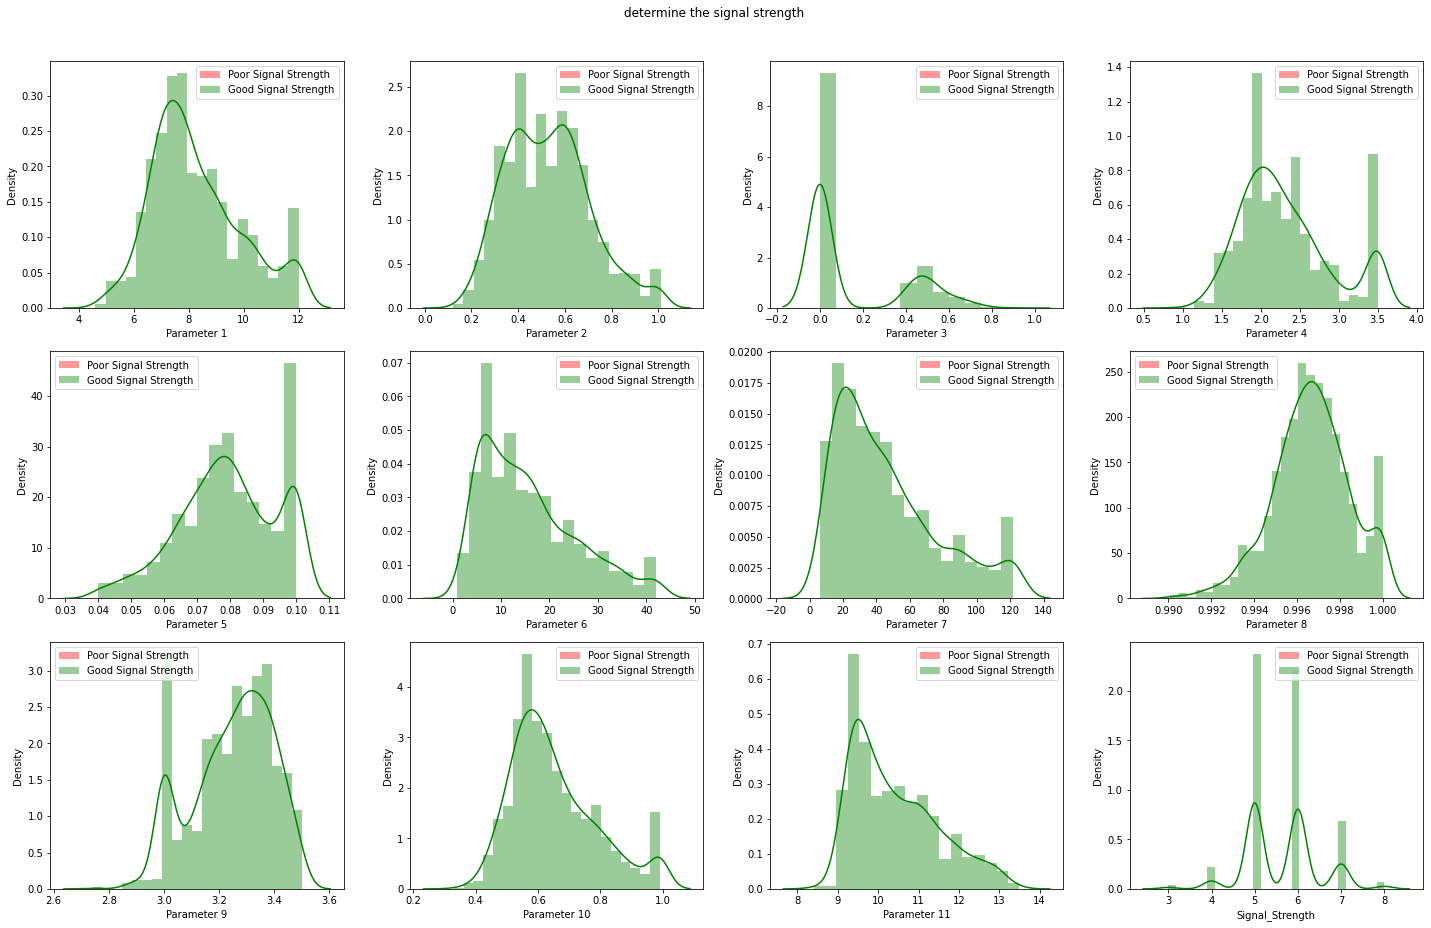

In [134]:
import warnings
warnings.simplefilter("ignore")

fig = plt.figure(figsize = (20, 25))
j = 0
for i in df_telecom.columns:
    plt.subplot(6, 4, j+1)
    j += 1
    sns.distplot(df_telecom[i][df_telecom['Signal_Strength']<0.50], color='r', label = 'Poor Signal Strength')
    sns.distplot(df_telecom[i][df_telecom['Signal_Strength']>0.50], color='g', label = 'Good Signal Strength')
    plt.legend(loc='best')
fig.suptitle('determine the signal strength ')
fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.show()

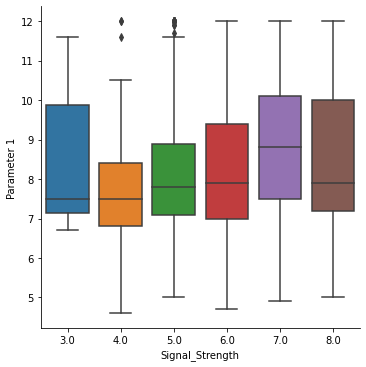

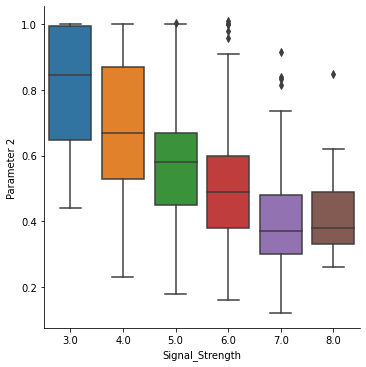

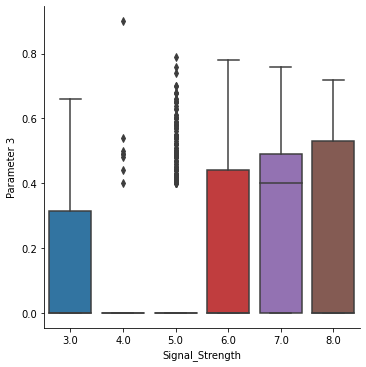

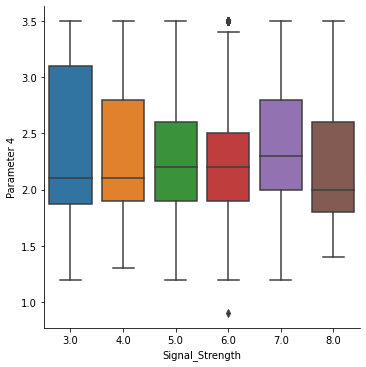

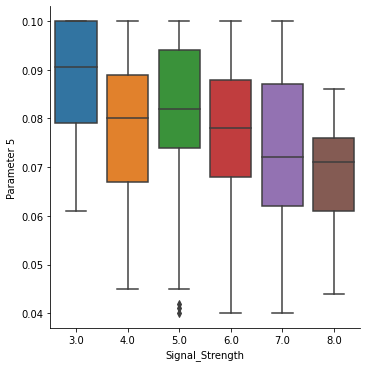

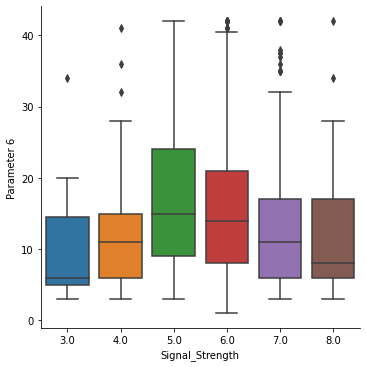

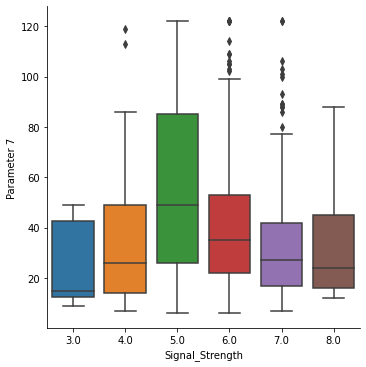

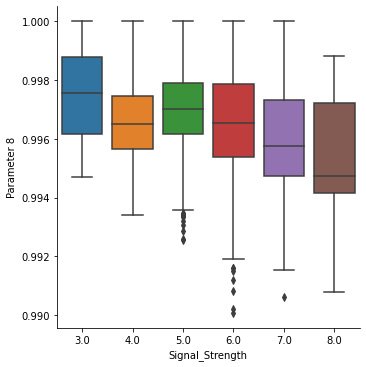

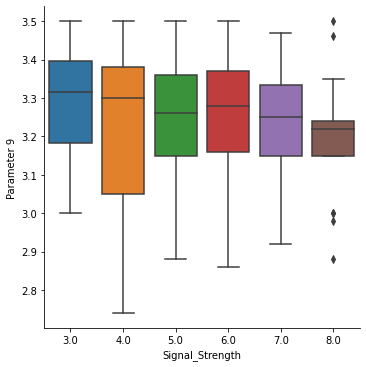

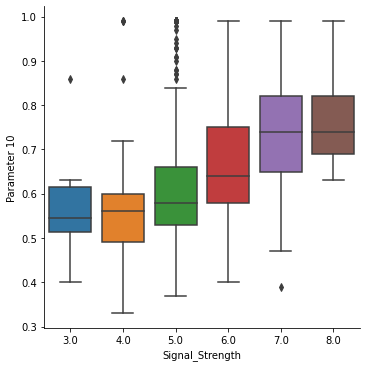

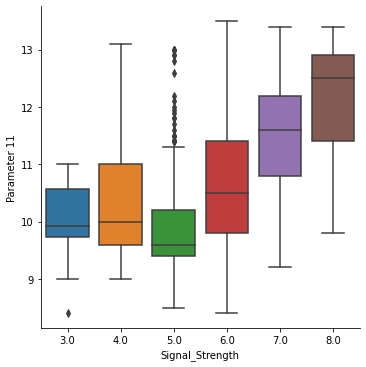

In [135]:
#Bi-variate Analaysis against target variable.
#Ignore Signal_Strength feature - which is the target variable. Plot each feature against target variable to understand the relationship.
for i in df_telecom:
    if i != 'Signal_Strength':
        sns.catplot(x='Signal_Strength',y=i,kind='box',data=df_telecom)

Step 3: Design, train, tune and test a neural network regressor.

 Hint: Use best approach to refine and tune the data or the model. Be highly experimental here

In [136]:
# split into input (X) and output (Y) variables
X = df_telecom.iloc[:,0:11]
y = df_telecom.iloc[:,11]

In [137]:
#Train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((951, 11), (951,), (408, 11), (408,))

In [138]:
##Normalize the data before building a model.
from sklearn.preprocessing import MinMaxScaler
scaler =  MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [139]:
# define base model

	# create model
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(10, input_shape=(11,), activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

model.summary()

Model: "sequential_21"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_62 (Dense)             (None, 10)                120       
_________________________________________________________________
dense_63 (Dense)             (None, 1)                 11        
Total params: 131
Trainable params: 131
Non-trainable params: 0
_________________________________________________________________


In [140]:
model.compile(loss= "mean_squared_error" , optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=["mean_squared_error"])
model_checkpoint_callback = keras.callbacks.ModelCheckpoint("NNRegressorModelChkpt.h5",save_best_only=True)
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=120, batch_size=32, callbacks=[model_checkpoint_callback])

Epoch 1/120
30/30 [==============================] - 1s 7ms/step - loss: 14.9394 - mean_squared_error: 14.9394 - val_loss: 2.1928 - val_mean_squared_error: 2.1928
Epoch 2/120
30/30 [==============================] - 0s 3ms/step - loss: 1.6934 - mean_squared_error: 1.6934 - val_loss: 1.4257 - val_mean_squared_error: 1.4257
Epoch 3/120
30/30 [==============================] - 0s 3ms/step - loss: 1.0726 - mean_squared_error: 1.0726 - val_loss: 1.2103 - val_mean_squared_error: 1.2103
Epoch 4/120
30/30 [==============================] - 0s 3ms/step - loss: 0.9092 - mean_squared_error: 0.9092 - val_loss: 1.0818 - val_mean_squared_error: 1.0818
Epoch 5/120
30/30 [==============================] - 0s 3ms/step - loss: 0.9519 - mean_squared_error: 0.9519 - val_loss: 0.9892 - val_mean_squared_error: 0.9892
Epoch 6/120
30/30 [==============================] - 0s 3ms/step - loss: 0.7304 - mean_squared_error: 0.7304 - val_loss: 0.8805 - val_mean_squared_error: 0.8805
Epoch 7/120
30/30 [=============

In [141]:
pred_train= model.predict(X_train)
print("Prediction on training set:", np.sqrt(mean_squared_error(y_train,pred_train)))

pred= model.predict(X_test)
print("Prediction on test set:", np.sqrt(mean_squared_error(y_test,pred)))

Prediction on training set: 0.66558284
Prediction on test set: 0.6475119


dict_keys(['loss', 'mean_squared_error', 'val_loss', 'val_mean_squared_error'])


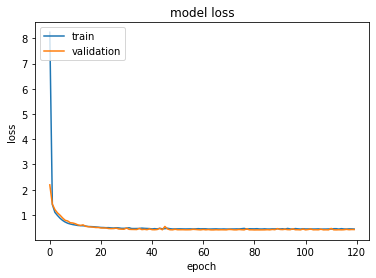

In [142]:
print(history.history.keys())
# "Loss"
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Step 4: Pickle the model for future use.

In [143]:
# Save to file in the current working directory
model.save('NNRegressor_model.h5')

In [144]:
# Load from file
new_model = tf.keras.models.load_model('NNRegressor_model.h5')

In [145]:
new_model.summary()

Model: "sequential_21"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_62 (Dense)             (None, 10)                120       
_________________________________________________________________
dense_63 (Dense)             (None, 1)                 11        
Total params: 131
Trainable params: 131
Non-trainable params: 0
_________________________________________________________________


In [146]:
new_model.compile(loss= "mean_squared_error" , optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=["mean_squared_error"])

In [147]:
loss, acc = new_model.evaluate(X_test, y_test, verbose=2)
print('Restored model, accuracy: {:.2f}%'.format(100 * acc))

13/13 - 0s - loss: 0.4193 - mean_squared_error: 0.4193
Restored model, accuracy: 41.93%


Additional research - learning purpose ONLY.

Another approach of building model using sklearn library - kerasRegressor.

In [148]:
def keras_model():
  modelK = tf.keras.Sequential()
  modelK.add(tf.keras.layers.Dense(20, input_shape=(11,), kernel_initializer='normal', activation='relu'))
  modelK.add(tf.keras.layers.Dense(12, kernel_initializer='normal', activation='relu'))
  modelK.add(tf.keras.layers.Dense(9))
  modelK.compile(loss= "mean_squared_error" , optimizer="adam", metrics=["mean_squared_error"])
  return modelK


In [149]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# fix random seed for reproducibility
seed = 7
np.random.seed(seed)

# evaluate model
estimators = []
estimators.append(('standardize', StandardScaler()))
estimators.append(('mlp', KerasRegressor(build_fn=keras_model, epochs=15, batch_size=32, verbose=0)))

pipeline = Pipeline(estimators)

In [150]:
kfold = KFold(n_splits=10)
results = cross_val_score(pipeline, X.values, y.values, cv=kfold, n_jobs=1)
print("Results: %.2f (%.2f) MSE" % (results.mean(), results.std()))

Results: -0.76 (0.07) MSE
